<a href="https://colab.research.google.com/github/Vedant28082005/CV-2026-H10/blob/main/LAB3/CV_LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import scipy.stats as stats

In [16]:
print(int(6.5/2))

3


In [17]:
img = cv2.imread("/content/sample.png" , cv2.IMREAD_GRAYSCALE)

In [18]:
sample = cv2.imread("/content/sample.png")

In [19]:
def add_salt_pepper(img , prob = 0.3):
  noisy = img.copy()

  random = np.random.rand(*noisy.shape)
  noisy[random < prob/2] = 0
  noisy[random > 1-prob/2] = 255

  return noisy

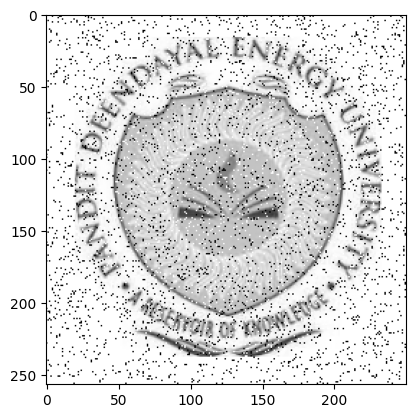

In [20]:
noisy = add_salt_pepper(img , 0.1)
plt.imshow(noisy , cmap='gray')

In [21]:
def median_filter(img, k , s=0):
    output = img.copy()

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if (i + k + s<= img.shape[0]) and (j + k + s<= img.shape[1]):
                patch = img[i:i+k+s, j:j+k+s]
                output[i, j] = np.median(patch)

    return output

In [22]:
def mean_filter(img, k , s=0):
    output = img.copy()

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if (i + k + s <= img.shape[0]) and (j + k + s <= img.shape[1]):
                patch = img[i:i+k+s, j:j+k+s]
                output[i, j] = np.average(patch)

    return output

In [23]:
img_me = median_filter(noisy , 3 , 2)
img_avg = mean_filter(noisy , 3 , 2)

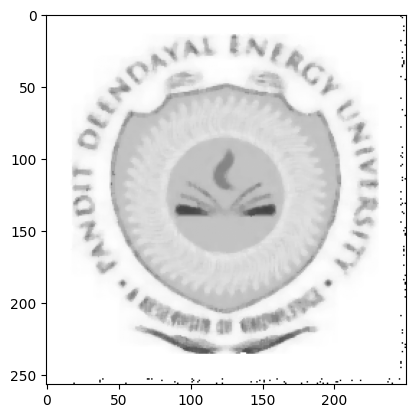

In [24]:
plt.imshow(img_me , cmap='gray')

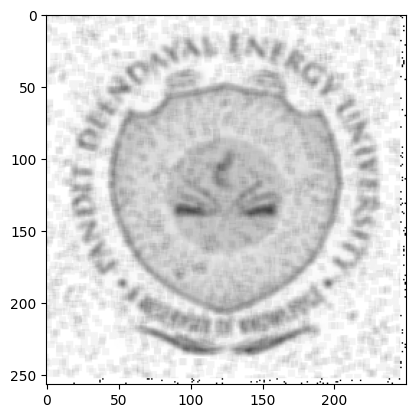

In [25]:
plt.imshow(img_avg , cmap='gray')

In [26]:
img_avg.shape

(257, 250)

In [45]:
def with_stride(img, k, s=1):

    p = k // 2

    h, w = img.shape

    padded = np.pad(img, p, mode='reflect')

    op_h = ((h + 2*p - k) // s) + 1
    op_w = ((w + 2*p - k) // s) + 1

    og = np.zeros((op_h, op_w), dtype=img.dtype)

    for i in range(op_h):
        for j in range(op_w):
            window = padded[i*s:i*s+k, j*s:j*s+k]
            og[i, j] = np.median(window)

    return og

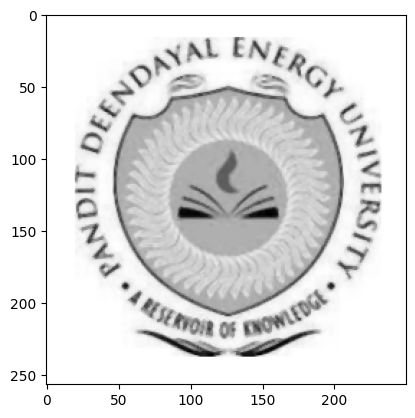

In [46]:
img4 = with_stride(img , 3 , 1)
plt.imshow(img4 , cmap='gray')